# Полный цикл работы с данными. От нормализации до расчётов и визуализации.

- Автор: Бышин М.И. (hh.ru/resume/3a27e4d7ff0ef40ab90039ed1f6f445a567078)

Задание:
- Изучить датасет, посмотреть основные статистики по столбцам и все, что может быть интересно при первом знакомстве с данными.
- Визуализировать количество персон по датам первого входа (ось X) на графике.
- Выбрать клиентов, дата первого входа которых была в 2023 г., затем посмотреть, сколько из них до сих пор пользуются сервисом. Результат дополнительно описать или визуализировать.
- Количество устройств на аккаунте – построить график распределения столбца.
- Показать количество дней playtrack для разных диапазонов даты первого входа (например, сгруппировать по сезонам – осень 2023, зима 2024 и т.п.).
- Посмотреть, какие жанры более популярны, какие менее.


#### Комментарий:
- Предобработку данных можно было-бы сделать покороче, например, оставить занчения типа `float64`.
- Где-то не хватило конкретики по заданиям, например, с дубликатами в столбце `person_id`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Загружаем данные
vip = pd.read_csv('C:/Users/Max Man/Downloads/VIP_test_fin.csv') # У вас будет своя ссылка на файл

## Предобработка данных

#### Знакомство

In [3]:
# Знакомимся
vip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2459 entries, 0 to 2458
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          2459 non-null   int64  
 1   person_id                           2459 non-null   object 
 2   first_login_dt                      2362 non-null   object 
 3   last_playtrack_dt                   1995 non-null   object 
 4   fl_playtrack_day_90d                2440 non-null   float64
 5   last_main_screen_dt                 2158 non-null   object 
 6   cnt_device_day_30d                  2438 non-null   float64
 7   fl_app_push_on_music                1420 non-null   float64
 8   cnt_days_playtrack_day_90d          2442 non-null   float64
 9   fl_playtrack30_pop_day_30d          2441 non-null   float64
 10  fl_playtrack30_rap_day_30d          2430 non-null   float64
 11  fl_playtrack30_dance_day_30d        2437 no

In [4]:
# Визуальный осмотр
display(vip)

,Unnamed: 0,person_id,first_login_dt,last_playtrack_dt,fl_playtrack_day_90d,last_main_screen_dt,cnt_device_day_30d,fl_app_push_on_music,cnt_days_playtrack_day_90d,fl_playtrack30_pop_day_30d,fl_playtrack30_rap_day_30d,fl_playtrack30_dance_day_30d,fl_playtrack30_rock_day_30d,fl_playtrack30_electronics_day_30d
0,0,pers195918153,2023-02-09,2024-05-08,0.0,2023-04-24,0.0,1.0,1.0,0.0,0.0,0.0,NaN,0.0
1,1,pers612132512,2023-06-18,2024-10-17,0.0,2024-06-28,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,pers585716209,2024-09-01,2024-10-07,0.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,pers720630892,2023-06-12,2023-08-09,0.0,2024-05-04,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,4,pers752255130,2023-07-07,2024-10-11,1.0,2024-10-18,0.0,NaN,38.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2454,2454,pers522433067,2022-11-09,2022-11-01,1.0,2023-03-14,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0
2455,2455,pers602852424,2023-12-17,2023-06-10,0.0,2024-10-19,1.0,0.0,24.0,0.0,0.0,0.0,0.0,1.0
2456,2456,pers239350271,2024-03-22,2022-12-11,0.0,2023-12-26,1.0,1.0,60.0,1.0,0.0,0.0,0.0,NaN
2457,2457,pers808276086,2024-09-21,2023-11-21,1.0,2024-10-12,1.0,1.0,61.0,1.0,0.0,0.0,0.0,1.0


- Типы данных в столбцах `first_login_dt`, `last_playtrack_dt` и `last_main_screen_dt` не соответствуют содержимому, меняем на `date`.
- Типы данных в столбцах `fl_playtrack_day_90d`, `cnt_device_day_30d`, `fl_app_push_on_music`, `fl_app_push_on_music`,`cnt_days_playtrack_day_90d`, `fl_playtrack30_pop_day_30d`,`fl_playtrack30_rap_day_30d`, `fl_playtrack30_dance_day_30d`, `fl_playtrack30_rock_day_30d`,`fl_playtrack30_electronics_day_30d` не соответствуют содержимому, меняем на `int16`
- Пропуски содержатся во всех столбцах, кроме: `Unnamed` и `person_id `. Критичность этого параметра определим позже.
- Проверка на уникальные значения и дубликаты позже.

### Оптимизируем типы данных

In [5]:
# Преобразование формата
vip['first_login_dt'] = pd.to_datetime(vip['first_login_dt'])
vip['last_playtrack_dt'] = pd.to_datetime(vip['last_playtrack_dt'])
vip['last_main_screen_dt'] = pd.to_datetime(vip['last_main_screen_dt'])

In [6]:
def convert_columns(vip):
    """
    Преобразуем указанные столбцы в формат int16, сохраняя NaN без изменений.
    Изменения применяются напрямую к датафрейму (inplace).
    """
    # Список столбцов для преобразования
    columns_to_convert = [
        'fl_playtrack_day_90d',
        'cnt_device_day_30d',
        'fl_app_push_on_music',
        'cnt_days_playtrack_day_90d',
        'fl_playtrack30_pop_day_30d',
        'fl_playtrack30_rap_day_30d',
        'fl_playtrack30_dance_day_30d',
        'fl_playtrack30_rock_day_30d',
        'fl_playtrack30_electronics_day_30d'
    ]
    # Преобразование с сохранением NaN
    for column in columns_to_convert:
        if column in vip.columns:
            vip[column] = vip[column].astype('Int16')
        else:
            print(f'Столбец {column} не найден, пропуск')
    # Не возвращаем ничего, т.к. изменения inplace
    return None

# Применяем функцию:
convert_columns(vip)

In [7]:
# Проверяем
vip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2459 entries, 0 to 2458
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Unnamed: 0                          2459 non-null   int64         
 1   person_id                           2459 non-null   object        
 2   first_login_dt                      2362 non-null   datetime64[ns]
 3   last_playtrack_dt                   1995 non-null   datetime64[ns]
 4   fl_playtrack_day_90d                2440 non-null   Int16         
 5   last_main_screen_dt                 2158 non-null   datetime64[ns]
 6   cnt_device_day_30d                  2438 non-null   Int16         
 7   fl_app_push_on_music                1420 non-null   Int16         
 8   cnt_days_playtrack_day_90d          2442 non-null   Int16         
 9   fl_playtrack30_pop_day_30d          2441 non-null   Int16         
 10  fl_playtrack30_rap_day_3

In [8]:
# Смотрим анамалии в датах
vip.describe()

,Unnamed: 0,first_login_dt,last_playtrack_dt,fl_playtrack_day_90d,last_main_screen_dt,cnt_device_day_30d,fl_app_push_on_music,cnt_days_playtrack_day_90d,fl_playtrack30_pop_day_30d,fl_playtrack30_rap_day_30d,fl_playtrack30_dance_day_30d,fl_playtrack30_rock_day_30d,fl_playtrack30_electronics_day_30d
count,2459.000000,2362,1995,2440.0,2158,2438.0,1420.0,2442.0,2441.0,2430.0,2437.0,2434.0,2437.0
mean,1229.000000,2023-08-15 16:50:11.685012736,2024-04-14 11:56:45.112782080,0.405328,2024-03-09 02:22:07.896200192,0.359311,0.547887,10.262899,0.238017,0.188477,0.196143,0.20378,0.194091
min,0.000000,2022-11-01 00:00:00,2022-11-01 00:00:00,0.0,2022-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,614.500000,2022-12-10 00:00:00,2023-11-24 00:00:00,0.0,2023-08-25 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,1229.000000,2023-06-30 12:00:00,2024-07-08 00:00:00,0.0,2024-06-12 12:00:00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,1843.500000,2024-04-13 00:00:00,2024-10-13 00:00:00,1.0,2024-10-11 00:00:00,1.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0
max,2458.000000,2024-10-19 00:00:00,2024-10-20 00:00:00,1.0,2024-10-19 00:00:00,2.0,1.0,88.0,1.0,1.0,1.0,1.0,1.0
std,709.996479,NaN,NaN,0.491056,NaN,0.481604,0.497877,21.108537,0.425957,0.391173,0.397159,0.40289,0.395581


Аномалий в датах не наблюдается, в остальных столбцах простые числовые данные.

### Проверяем наличие пропусков

In [9]:
# Проверяем наличие пропусков
vip.isna().sum()

Unnamed: 0                               0
person_id                                0
first_login_dt                          97
last_playtrack_dt                      464
fl_playtrack_day_90d                    19
last_main_screen_dt                    301
cnt_device_day_30d                      21
fl_app_push_on_music                  1039
cnt_days_playtrack_day_90d              17
fl_playtrack30_pop_day_30d              18
fl_playtrack30_rap_day_30d              29
fl_playtrack30_dance_day_30d            22
fl_playtrack30_rock_day_30d             25
fl_playtrack30_electronics_day_30d      22
dtype: int64

Обрабатывать пропуски будем в каждом конкретном случае по мере необходимости.

### Проверяем наличие дубликатов

In [10]:
### Проверяем наличие явных дубликатов
vip.duplicated().sum()

np.int64(0)

In [12]:
# Проверяем наличие неявных дубликатов
duplicates = vip[vip['person_id'].duplicated(keep=False)]

# Сортируем по person_id
duplicates_sorted = duplicates.sort_values('person_id')

# Выводим все строки с дубликатами
print(f"Всего строк с дубликатами: {len(duplicates_sorted)}")

Всего строк с дубликатами: 770


In [15]:
# Визуально осматриваем
display(duplicates_sorted)

,Unnamed: 0,person_id,first_login_dt,last_playtrack_dt,fl_playtrack_day_90d,last_main_screen_dt,cnt_device_day_30d,fl_app_push_on_music,cnt_days_playtrack_day_90d,fl_playtrack30_pop_day_30d,fl_playtrack30_rap_day_30d,fl_playtrack30_dance_day_30d,fl_playtrack30_rock_day_30d,fl_playtrack30_electronics_day_30d
2437,2437,pers003942942,2023-05-09,2024-10-17,0,2024-09-23,0,<NA>,0,1,0,0,0,0
2042,2042,pers003942942,2023-08-08,2024-10-05,0,2024-06-08,0,<NA>,0,0,0,0,0,0
1195,1195,pers005023794,2022-12-10,2024-10-19,0,2023-12-10,0,<NA>,0,0,1,0,0,0
1498,1498,pers005023794,2024-03-08,2024-10-19,1,2024-04-19,0,<NA>,37,1,1,0,0,0
1666,1666,pers009563451,2022-11-08,2023-11-22,0,2024-02-10,1,<NA>,9,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2123,2123,pers991518908,2023-12-13,2024-10-20,0,2024-04-13,0,1,25,0,0,0,0,0
1375,1375,pers995576869,2024-04-21,2023-12-31,0,2024-05-02,0,<NA>,0,0,1,1,0,0
1893,1893,pers995576869,2024-07-15,2024-10-19,0,2024-10-09,1,<NA>,1,0,0,1,1,0
2107,2107,pers999417287,2023-06-20,2023-05-27,0,2024-10-18,0,1,75,1,0,0,0,0


In [16]:
# Смотрим кол-во уникальных значений в столбце
vip['person_id'].unique()

array(['pers195918153', 'pers612132512', 'pers585716209', ...,
       'pers602852424', 'pers808276086', 'pers279980219'],
      shape=(2074,), dtype=object)

Дубликаты есть в `person_id`. Оставлю их без изменений. В зависимости от задачи, можно было-бы предпринять какие-либо шаги по нормализации данных. 

## Решение задач

### Визуализировать количество персон по датам первого входа (ось X) на графике.

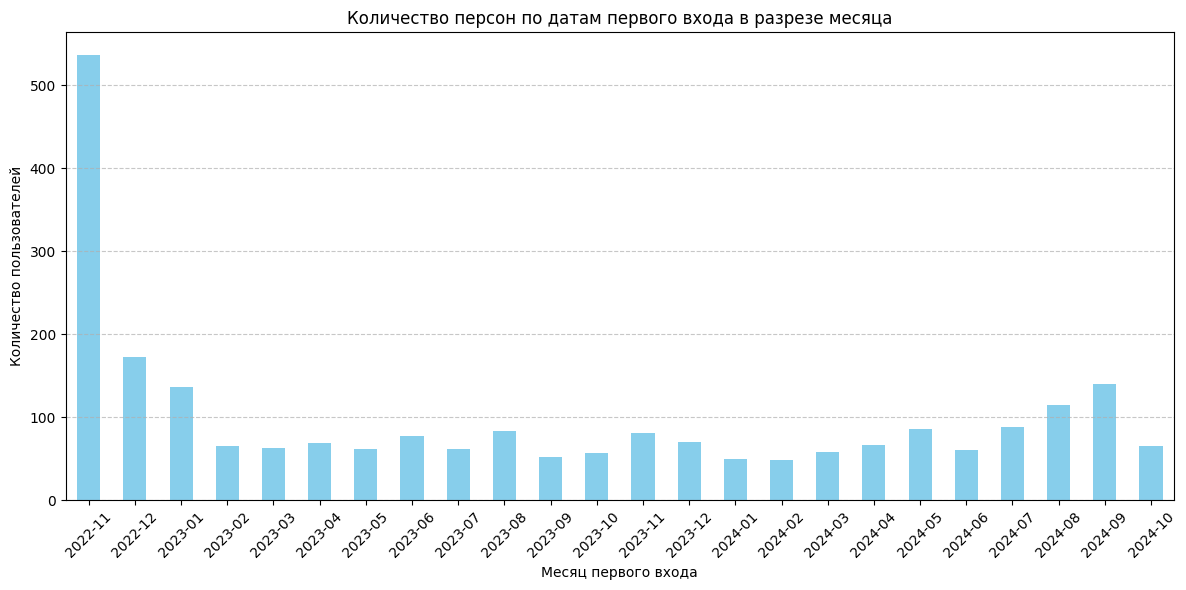

In [18]:
# Извлекаем год-месяц для группировки и создаём новый столбец
vip['login_ym'] = vip['first_login_dt'].dt.to_period('M') # Создаём новый столбец

# Строим график
plt.figure(figsize=(12, 6))
login_counts = vip['login_ym'].value_counts().sort_index()
login_counts.plot(kind='bar', color='skyblue')
plt.title('Количество персон по датам первого входа в разрезе месяца')
plt.xlabel('Месяц первого входа')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Выбрать клиентов, дата первого входа которых была в 2023 г., затем посмотреть, сколько из них до сих пор пользуются сервисом. Результат дополнительно описать или визуализировать

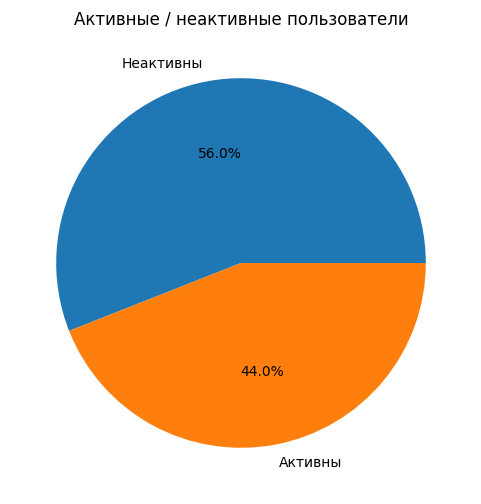

In [38]:
# Выбираем пользователей с первой датой 2023 года
users_2023 = vip[vip['first_login_dt'].dt.year == 2023].copy() # СОздаём новый столбец

# Определяем активных пользователей
last_date = pd.to_datetime('2024-07-20')  # Дату ставим любую в зависимости от задания
users_2023['is_active'] = pd.to_datetime(users_2023['last_main_screen_dt']) > (last_date - pd.Timedelta(days=30)) # были в системе в последние 30 дней, напрмер

# Визуализация
active_stats = users_2023['is_active'].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
active_stats.plot(kind='pie', autopct='%1.1f%%', labels=['Неактивны', 'Активны'])
plt.title('Активные / неактивные пользователи')
plt.ylabel('')
plt.show()

In [23]:
# Статистика
print(f"Всего пользователей 2023 года: {len(users_2023)}")
print(f"Из них активны: {users_2023['is_active'].sum()} ({active_stats[True]:.1f}%)")

Всего пользователей 2023 года: 877
Из них активны: 386 (44.0%)


### Количество устройств на аккаунте – построить график распределения столбца

In [25]:
# Смотрим соотношение данных в столбце
vip['cnt_device_day_30d'].value_counts(dropna=False)

cnt_device_day_30d
0       1564
1        872
<NA>      21
2          2
Name: count, dtype: Int64

In [27]:
# Удаляем строки с пропусками
cnt_clean = vip.dropna(subset=['cnt_device_day_30d']).copy()
print(f"Было удалено {len(vip) - len(cnt_clean)} строк с пропусками в столбце")

Было удалено 21 строк с пропусками в столбце


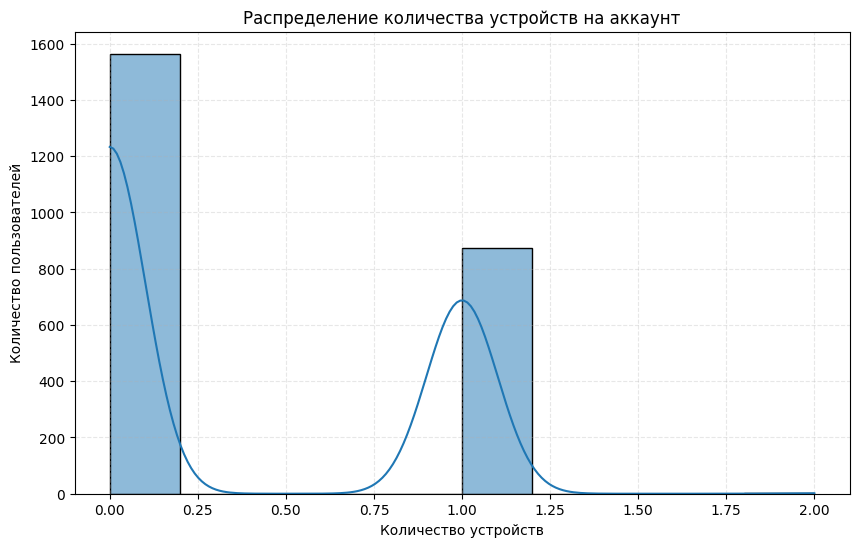

In [33]:
# Визуализация гистограмма с KDE
plt.figure(figsize=(10, 6))
sns.histplot(data=cnt_clean, x='cnt_device_day_30d', bins=10, kde=True)
plt.title('Распределение количества устройств на аккаунт')
plt.xlabel('Количество устройств')
plt.ylabel('Количество пользователей')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Показать количество дней playtrack для разных диапазонов даты первого входа (например, сгруппировать по сезонам – осень 2023, зима 2024 и т.п.).

In [34]:
# Удаляем строки с пропусками
vip_clean = vip.dropna(subset=['first_login_dt']).copy()
print(f"Было удалено {len(vip) - len(vip_clean)} строк с пропусками в столбце")

Было удалено 97 строк с пропусками в столбце


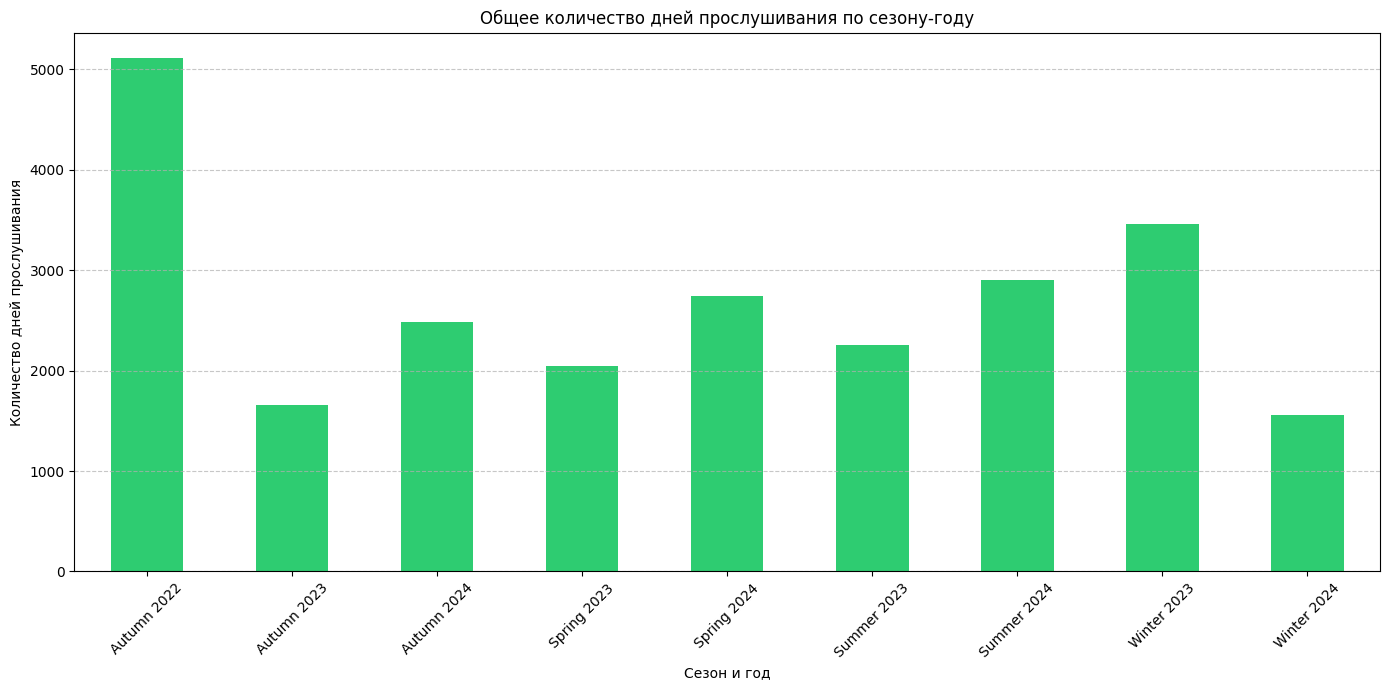

In [35]:
# Функция для определения сезона и года
def get_season_year(date):
    year = date.year
    month = date.month
    if month in [12, 1, 2]:
        season = 'Winter'
        if month == 12:
            year += 1
    elif month in [3, 4, 5]:
        season = 'Spring'
    elif month in [6, 7, 8]:
        season = 'Summer'
    else:
        season = 'Autumn'
    return f"{season} {year}"

# Создаем столбец с сезоном и годом
vip_clean['season_year'] = vip_clean['first_login_dt'].apply(get_season_year)

# Группируем по сезону-году и считаем сумму дней прослушивания
season_stats = vip_clean.groupby('season_year')['cnt_days_playtrack_day_90d'].sum().sort_index()

# Визуализация
plt.figure(figsize=(14, 7))
season_stats.plot(kind='bar', color='#2ecc71')
plt.title('Общее количество дней прослушивания по сезону-году')
plt.xlabel('Сезон и год')
plt.ylabel('Количество дней прослушивания')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Выводим статистику
print("\nОбщее количество дней прослушивания по сезонам:")
print(season_stats.to_string())


Общее количество дней прослушивания по сезонам:
season_year
Autumn 2022    5110
Autumn 2023    1659
Autumn 2024    2481
Spring 2023    2043
Spring 2024    2740
Summer 2023    2253
Summer 2024    2904
Winter 2023    3458
Winter 2024    1557


### Посмотреть, какие жанры более популярны, какие менее

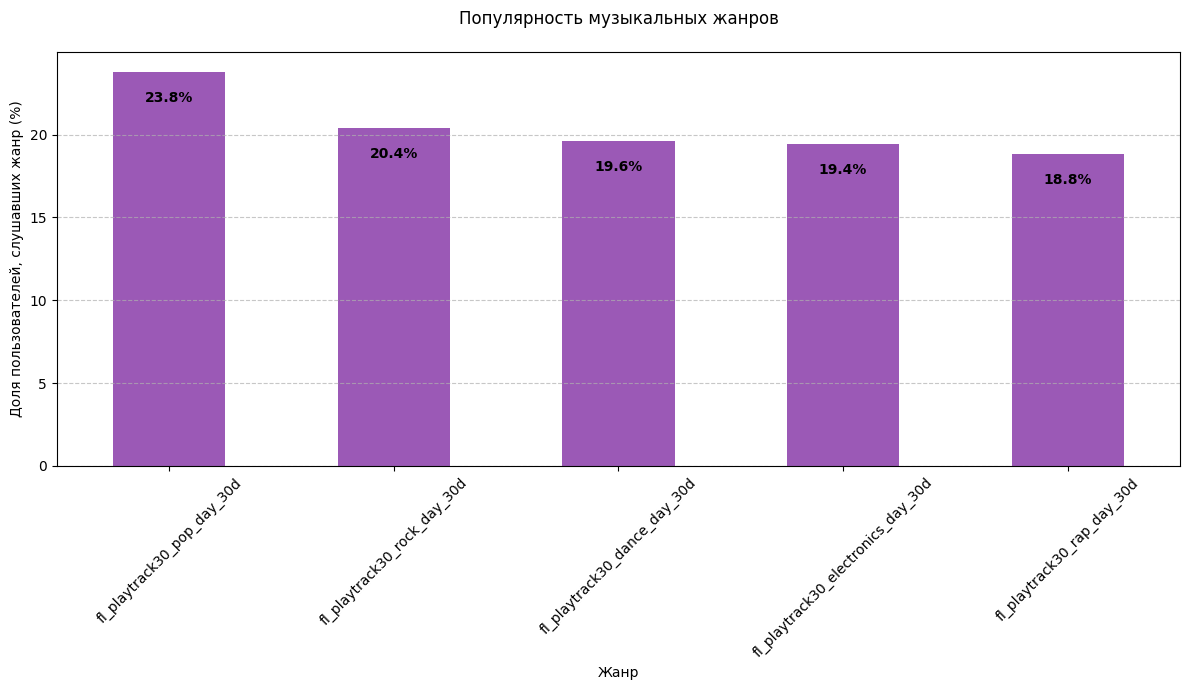

In [37]:
# Собираем статистику по жанрам
genres = ['pop', 'rap', 'dance', 'rock', 'electronics'] # Создаём пеерменную с жанрами

# Функция для выделения и подсчёта жанров в процентах
genre_stats = vip[[f'fl_playtrack30_{g}_day_30d' for g in genres]].mean() * 100 
genre_stats = genre_stats.sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 7))
ax = genre_stats.plot(kind='bar', color='#9b59b6')
plt.title('Популярность музыкальных жанров', pad=20)
plt.xlabel('Жанр')
plt.ylabel('Доля пользователей, слушавших жанр (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем подписи значений
for i, v in enumerate(genre_stats):
    ax.text(i, v - 2, f"{v:.1f}%", 
            ha='center', 
            va='bottom',
            fontsize=10,
            fontweight='bold')
plt.tight_layout()
plt.show()